# Rest & Recreation - AI Clothing Recommender (29cm 데이터)
> **Jupyter Custom Photo Matcher (Balanced Mode V3 - 29cm dataset)**

이 노트북은 `test_custom_clothing_backup.ipynb`의 구조를 유지하면서 모델 데이터로 `29cm_exclusive_women_classified.csv`를 사용합니다.
실행 전에 파일이 동일 폴더에 있는지 확인하세요. (필요 시 누락 컬럼은 자동으로 채웁니다.)

In [1]:
import os, sys, colorsys
if sys.platform == 'win32':
    try: sys.stdout.reconfigure(encoding='utf-8')
    except: pass
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from scipy.sparse import hstack, csr_matrix
from recommender import ClothingRecommender, detect_color_label_from_image
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)
print('Libraries loaded OK')

Libraries loaded OK


In [2]:
# Prepare and load 29cm dataset (backup original augmented CSV first)
from pathlib import Path
import shutil, pandas as pd
BASE = Path('.').resolve()
aug = BASE / 'rest_recreation_600_labeled_augmented.csv'
if aug.exists():
    suf = 0
    cand = BASE / f'{aug.name}.bak'
    while cand.exists():
        suf += 1
        cand = BASE / f'{aug.name}.bak{suf}'
    shutil.copy2(aug, cand)
    print('Backed up', aug, '->', cand)
# prepare 29cm source CSV
src29 = BASE / '29cm_exclusive_women_classified.csv'
prepared = BASE / '29cm_exclusive_prepared.csv'
if src29.exists():
    df29 = pd.read_csv(src29)
    defaults = {'fit_label':'일반핏', 'length_label':'기본', 'color_label':'기타/믹스'}
    for c, d in defaults.items():
        if c not in df29.columns: df29[c] = d
        else: df29[c] = df29[c].fillna(d)
    if 'product_name' not in df29.columns:
        if 'product_url' in df29.columns:
            df29['product_name'] = df29['product_url'].astype(str)
        elif 'brand' in df29.columns:
            df29['product_name'] = df29['brand'].astype(str)
        else:
            df29['product_name'] = 'UNKNOWN'
    df29.to_csv(prepared, index=False)
    print('Prepared 29cm CSV ->', prepared)
else:
    print('29cm source not found:', src29)
dataset_path = str(prepared) if prepared.exists() else 'rest_recreation_600_labeled.csv'
rec = ClothingRecommender(dataset_path, weight_mode='balanced')
print('Dataset loaded:', len(rec.df), 'items (from', dataset_path, ')')

Backed up C:\Project\PyCharmMiscProject\PythonProject02\RestAndRecreation\rest_recreation_600_labeled_augmented.csv -> C:\Project\PyCharmMiscProject\PythonProject02\RestAndRecreation\rest_recreation_600_labeled_augmented.csv.bak42
Prepared 29cm CSV -> C:\Project\PyCharmMiscProject\PythonProject02\RestAndRecreation\29cm_exclusive_prepared.csv
Dataset loaded: 1000 items (from C:\Project\PyCharmMiscProject\PythonProject02\RestAndRecreation\29cm_exclusive_prepared.csv )


## Input Your Clothing
- `CUSTOM_IMAGE_PATH` 에 준비한 옷 사진 경로를 기재하세요. (예: `test_input.jpg`)
- `CUSTOM_COLOR`는 공란(`''`)으로 두거나 임의 기재하셔도 AI가 **이미지 분석을 통해 실시간으로 자동 감지하여 수정**합니다.

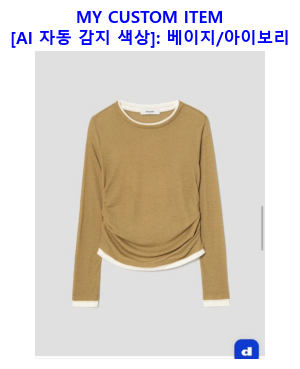

✓ 이미지 로드 성공: C:\Project\PyCharmMiscProject\PythonProject02\RestAndRecreation\옷09.jpg
✓ AI가 감지한 실제 옷 색상 라벨: "베이지/아이보리"


In [3]:
# ====== EDIT THESE VALUES ======
CUSTOM_IMAGE_PATH = "C:/Project/PyCharmMiscProject/PythonProject02/RestAndRecreation/옷09.jpg"           # <-- 직접 찍으신 사진 파일명
CUSTOM_NAME       = 'MY CUSTOM ITEM'            # 옷 이름
CUSTOM_CATEGORY   = '상의 (TOP)'                  # 대분류
CUSTOM_SUB_CAT    = '셔츠/블라우스'               # 소분류
CUSTOM_FIT        = '오버핏'
# ================================

if os.path.exists(CUSTOM_IMAGE_PATH):
    detected_color = detect_color_label_from_image(CUSTOM_IMAGE_PATH)
    plt.figure(figsize=(4, 4))
    plt.imshow(Image.open(CUSTOM_IMAGE_PATH))
    plt.title(f'{CUSTOM_NAME}\n[AI 자동 감지 색상]: {detected_color}', color='blue', fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.show()
    print(f'✓ 이미지 로드 성공: {CUSTOM_IMAGE_PATH}')
    print(f'✓ AI가 감지한 실제 옷 색상 라벨: \"{detected_color}\"')
else:
    print('❌ Image NOT found:', CUSTOM_IMAGE_PATH)
    print('👉 본인이 비교해보고 싶은 옷 사진을 찍어 RestAndRecreation 폴더에 ' + CUSTOM_IMAGE_PATH + ' 라는 이름으로 넣어주세요.')

## Clothing Zone & Background Detection Visualization

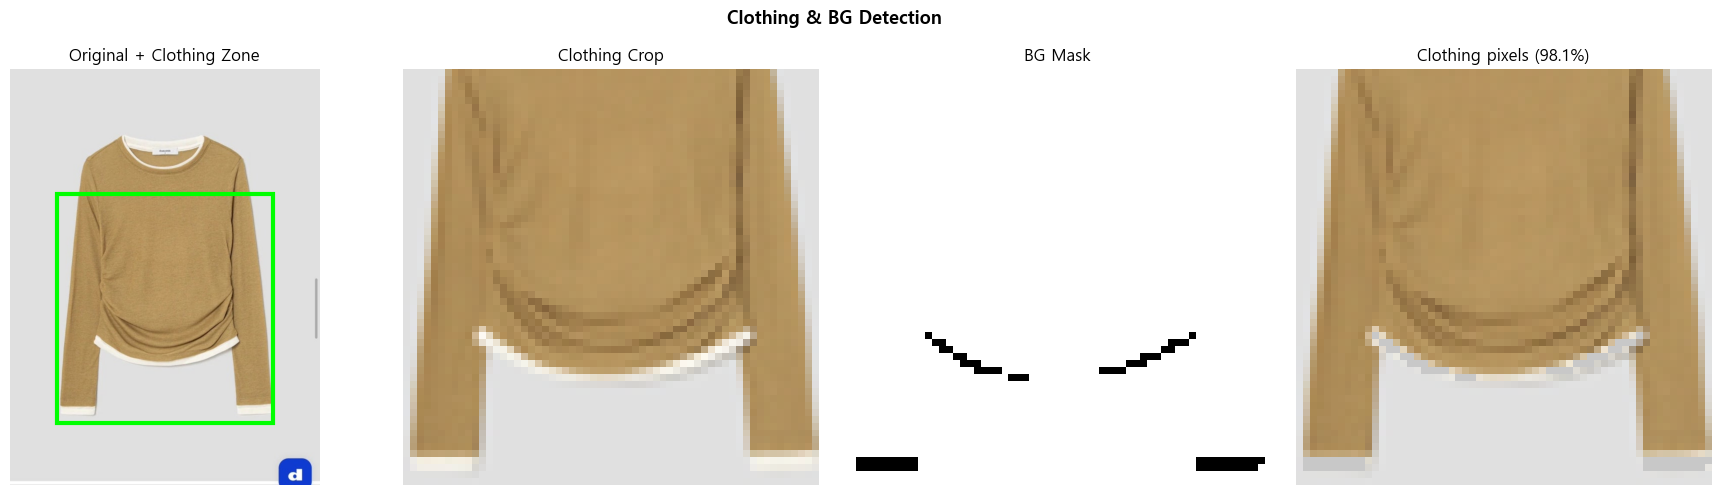

In [4]:
CROP_TOP    = 0.22
CROP_BOTTOM = 0.90
CROP_LEFT   = 0.10
CROP_RIGHT  = 0.90

def hue_distance(h1, h2):
    d = abs(h1 - h2)
    return min(d, 1.0 - d)

def get_dominant_bg_hues(border_pixels, top_k=3):
    border_hsv = np.array([
        colorsys.rgb_to_hsv(p[0]/255.0, p[1]/255.0, p[2]/255.0)
        for p in border_pixels
    ])
    saturated = border_hsv[border_hsv[:, 1] > 0.18]
    dominant_hues = []
    if len(saturated) >= 8:
        NUM_BINS = 18
        h_hist, h_edges = np.histogram(saturated[:, 0], bins=NUM_BINS, range=(0.0, 1.0))
        top_bins = np.argsort(h_hist)[::-1]
        for bi in top_bins[:top_k]:
            if h_hist[bi] == 0:
                break
            center_h = (h_edges[bi] + h_edges[bi + 1]) / 2.0
            mask_bin = (saturated[:, 0] >= h_edges[bi]) & (saturated[:, 0] < h_edges[bi + 1])
            avg_s = saturated[mask_bin, 1].mean() if mask_bin.any() else 0.5
            dominant_hues.append((center_h, avg_s))
    else:
        bg_mean = border_pixels.mean(axis=0)
        bg_h, bg_s, _ = colorsys.rgb_to_hsv(bg_mean[0]/255.0, bg_mean[1]/255.0, bg_mean[2]/255.0)
        if bg_s > 0.15:
            dominant_hues.append((bg_h, bg_s))
    return dominant_hues

def analyze_clothing_zone(img_path):
    if not os.path.exists(img_path):
        print('Cannot visualize: File not found')
        return []
    img = Image.open(img_path).convert('RGB')
    w, h = img.size
    import matplotlib.patches as patches
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    axes[0].imshow(img)
    rect = patches.Rectangle(
CROP_TOP    = 0.22
CROP_TOP    = 0.22
        linewidth=3, edgecolor='lime', facecolor='none'
    )
    axes[0].add_patch(rect)
    axes[0].set_title('Original + Clothing Zone')
    axes[0].axis('off')

    resized = np.array(img.resize((60, 60)))
    border_pixels = np.concatenate(
        [resized[0,:], resized[-1,:], resized[:,0], resized[:,-1]], axis=0
    ).astype(np.float32)
    dominant_bg_hues = get_dominant_bg_hues(border_pixels, top_k=3)

CROP_TOP    = 0.22
    crop_arr = np.array(crop.resize((60, 60))).astype(np.float32)
    pixels = crop_arr.reshape(-1, 3)

    mask = []
    for p in pixels:
        ph, ps, pv = colorsys.rgb_to_hsv(p[0]/255, p[1]/255, p[2]/255)
        is_white = (pv > 0.92 and ps < 0.12)
        is_black = (pv < 0.08)
        is_bg_color = any(
            bg_s > 0.20 and hue_distance(ph, bg_h) < 0.09 and ps > 0.15
            for bg_h, bg_s in dominant_bg_hues
        )
        mask.append(not is_white and not is_black and not is_bg_color)

    mask_arr = np.array(mask, dtype=np.uint8).reshape(60, 60) * 255
    removal_rate = 1.0 - sum(mask) / len(mask)
    kept_ratio = sum(mask) / len(mask) * 100
    kept_view = crop_arr.reshape(60, 60, 3).astype(np.uint8).copy()
    if removal_rate > 0.65:
        mask_arr[:] = 255
        kept_view = crop_arr.reshape(60, 60, 3).astype(np.uint8)
        kept_view_title = 'FALLBACK (clothing color = bg)'
    else:
        kept_view[mask_arr == 0] = [200, 200, 200]
        kept_view_title = 'Clothing pixels ({:.1f}%)'.format(kept_ratio)

    axes[1].imshow(crop_arr.reshape(60, 60, 3).astype(np.uint8))
    axes[1].set_title('Clothing Crop')
    axes[1].axis('off')
    axes[2].imshow(mask_arr, cmap='gray'); axes[2].axis('off')
    axes[2].set_title('BG Mask')
    axes[3].imshow(kept_view); axes[3].axis('off')
    axes[3].set_title(kept_view_title)
    plt.suptitle('Clothing & BG Detection', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()
    return dominant_bg_hues

dominant_bg_hues = analyze_clothing_zone(CUSTOM_IMAGE_PATH)


In [ ]:
# Define recommend_custom_item before it's called to avoid NameError
def recommend_custom_item(img_path, name, main_cat, sub_cat, color='', fit='일반핏', top_n=5):
    import numpy as np
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import cosine_similarity
    from sklearn.preprocessing import normalize
    from scipy.sparse import hstack, csr_matrix

    try:
        img_emb = rec.extract_single_image_embedding(img_path)
        if img_emb is None:
            img_emb = np.zeros(512, dtype=np.float32)
    except Exception:
        img_emb = np.zeros(512, dtype=np.float32)
    img_emb = img_emb / (np.linalg.norm(img_emb) + 1e-8)

    color_hist = rec.extract_hsv_histogram(img_path) if hasattr(rec, 'extract_hsv_histogram') else np.zeros(16, dtype=np.float32)

    tfidf_name = TfidfVectorizer(analyzer='char_wb', ngram_range=(2,4), min_df=1, sublinear_tf=True)
    tfidf_color = TfidfVectorizer(analyzer='word')
    tfidf_cat = TfidfVectorizer(analyzer='word')
    tfidf_sub = TfidfVectorizer(analyzer='word')
    tfidf_fit = TfidfVectorizer(analyzer='word')

    names_all = list(rec.df['clean_name']) + [name]
    colors_all = list(rec.df['color_label']) + [color]
    cats_all = list(rec.df['main_category']) + [main_cat]
    subs_all = list(rec.df['sub_category']) + [sub_cat]
    fits_all = list(rec.df['fit_label']) + [fit]

    mat_name = normalize(tfidf_name.fit_transform(names_all))
    mat_color = normalize(tfidf_color.fit_transform(colors_all))
    mat_cat = normalize(tfidf_cat.fit_transform(cats_all))
    mat_sub = normalize(tfidf_sub.fit_transform(subs_all))
    mat_fit = normalize(tfidf_fit.fit_transform(fits_all))

    W_COLOR, W_HIST, W_NAME, W_IMAGE, W_CAT, W_SUB, W_FIT = 0.25, 0.15, 0.20, 0.20, 0.14, 0.04, 0.02
    text_matrix = hstack([mat_color * W_COLOR, mat_name * W_NAME, mat_cat * W_CAT, mat_sub * W_SUB, mat_fit * W_FIT])

    all_color_hists = np.vstack([np.load(rec.color_npy_path), color_hist])
    all_img_embs = np.vstack([np.load(rec.npy_path), img_emb])
    color_csr = csr_matrix(normalize(all_color_hists) * W_HIST)
    img_csr = csr_matrix(normalize(all_img_embs) * W_IMAGE)

    combined = normalize(hstack([text_matrix, color_csr, img_csr]), norm='l2', axis=1)
    custom_vec = combined[-1]
    dataset_vecs = combined[:-1]
    sims = cosine_similarity(custom_vec, dataset_vecs)[0]
    candidate_indices = np.argsort(sims)[::-1]

    same_color = [i for i in candidate_indices if rec.df.iloc[i]['color_label'] == color]
    if same_color:
        same_color_sub = [i for i in same_color if rec.df.iloc[i]['main_category'] == main_cat and rec.df.iloc[i]['sub_category'] == sub_cat]
        same_color_main = [i for i in same_color if rec.df.iloc[i]['main_category'] == main_cat and i not in same_color_sub]
        same_color_other = [i for i in same_color if i not in same_color_sub and i not in same_color_main]
        remaining = [i for i in candidate_indices if i not in same_color]
        candidate_indices = same_color_sub + same_color_main + same_color_other + remaining
    elif main_cat and sub_cat:
        same_sub = [i for i in candidate_indices if rec.df.iloc[i]['main_category'] == main_cat and rec.df.iloc[i]['sub_category'] == sub_cat]
        if len(same_sub) >= top_n:
            candidate_indices = same_sub

    if main_cat and len(candidate_indices) > top_n:
        same_cat = [i for i in candidate_indices if rec.df.iloc[i]['main_category'] == main_cat]
        if len(same_cat) >= top_n:
            candidate_indices = same_cat

    top_indices = candidate_indices[:top_n]
    results = []
    for idx in top_indices:
        item = rec.df.iloc[idx].to_dict()
        item['item_id'] = int(idx)
        item['similarity_score'] = float(sims[idx])
        results.append(item)
    return results

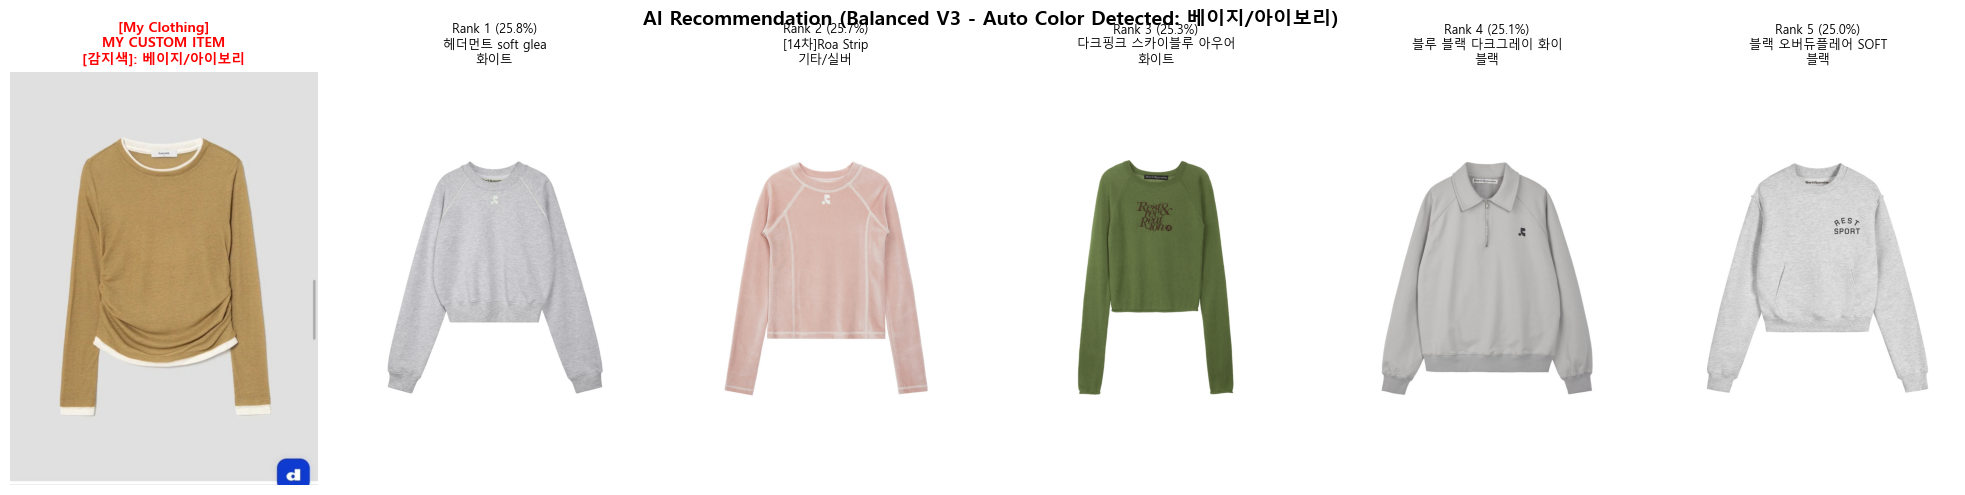

=== Results ===
1. 헤더먼트 soft gleam blouse (white) 16% 105,000 조건부 무료배송 단독 2.9천 5 (79) | 25.8% | 화이트
2. [14차]Roa Stripe PK Shirt_5colors 15% 52,700 조건부 무료배송 단독 4.1천 5 (200) | 25.7% | 기타/실버
3. 다크핑크 스카이블루 아우어솔티 Everyday Air Cotton T-Shirt / White 23% 32,900 조건부 무료배송 단독 762 4.5 (26) | 25.3% | 화이트
4. 블루 블랙 다크그레이 화이트 스카이블루 +3 르바 [27차][기장선택] Relaxed Boots Cut Denim - Light Blue 18% 89,060 조건부 무료배송 단독 1.7만 4.5 (531) | 25.1% | 블랙
5. 블랙 오버듀플레어 SOFT MINI CARDIGAN_MELANGE GREY 15% 58,650 조건부 무료배송 단독 1.4만 4.5 (1천) | 25.0% | 블랙


In [ ]:
# 이미지에서 실시간 색상 자동 추출
real_color = detect_color_label_from_image(CUSTOM_IMAGE_PATH) if os.path.exists(CUSTOM_IMAGE_PATH) else '화이트'

recommendations = recommend_custom_item(
    img_path=CUSTOM_IMAGE_PATH, name=CUSTOM_NAME,
    main_cat=CUSTOM_CATEGORY, sub_cat=CUSTOM_SUB_CAT,
    color=real_color, fit=CUSTOM_FIT, top_n=5
)
if not recommendations:
    print('❌ 먼저 비교하고 싶으신 이미지 파일을 준비해주세요!')
else:
    fig, axes = plt.subplots(1, 6, figsize=(20, 5))
    axes[0].imshow(Image.open(CUSTOM_IMAGE_PATH))
    axes[0].set_title('[My Clothing]\n' + CUSTOM_NAME[:15] + '\n[감지색]: ' + real_color,
                      color='red', fontsize=10, fontweight='bold')
    axes[0].axis('off')
    for i, item in enumerate(recommendations, 1):
        rec_img_path = os.path.join('static/images', 'item_{}.jpg'.format(item['item_id']))
        if os.path.exists(rec_img_path):
            axes[i].imshow(Image.open(rec_img_path))
        score = item['similarity_score'] * 100
        title = 'Rank {} ({:.1f}%)\n{}\n{}'.format(
            i, score, str(item['product_name'])[:14], item['color_label'])
        axes[i].set_title(title, fontsize=9)
        axes[i].axis('off')
    plt.suptitle(f'AI Recommendation (Balanced V3 - Auto Color Detected: {real_color})', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()
    print('=== Results ===')
    for i, item in enumerate(recommendations, 1):
        print('{}. {} | {:.1f}% | {}'.format(i, item['product_name'], item['similarity_score']*100, item['color_label']))